In [242]:
from src import *
from scipy.stats import norm

In [ ]:
def plott(data, title='Untitled', sampling_rate=1):
    padded_signal = np.pad(data, (0, 0), mode='constant')
    N = len(padded_signal)
    freq = np.fft.rfftfreq(N, d=1.0 / sampling_rate)
    spectrum = np.abs(np.fft.rfft(padded_signal))

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.2))
    ax[0].plot(data)
    ax[1].plot(freq, spectrum)
    ax[0].set_xlim(0, 49)
    ax[1].set_xlim(0, 0.5)
    ax[1].set_ylim(0, None)

    ax[0].set_xlabel(r'$n$')
    ax[0].set_ylabel(r'$s/\sigma$')
    ax[1].set_xlabel(r'$f$')

    ax[0].set_box_aspect(0.618)
    ax[1].set_box_aspect(0.618)

    fig.suptitle(title)

    fig.tight_layout()

    plt.show()

In [ ]:
di_vars = [LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]
spade_vars = [LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]


di_x = np.load(r'result/expt/noisy/di_5px.npz')['b']
spade_x = np.load(r'result/expt/noisy/spade_5px.npz')['b']

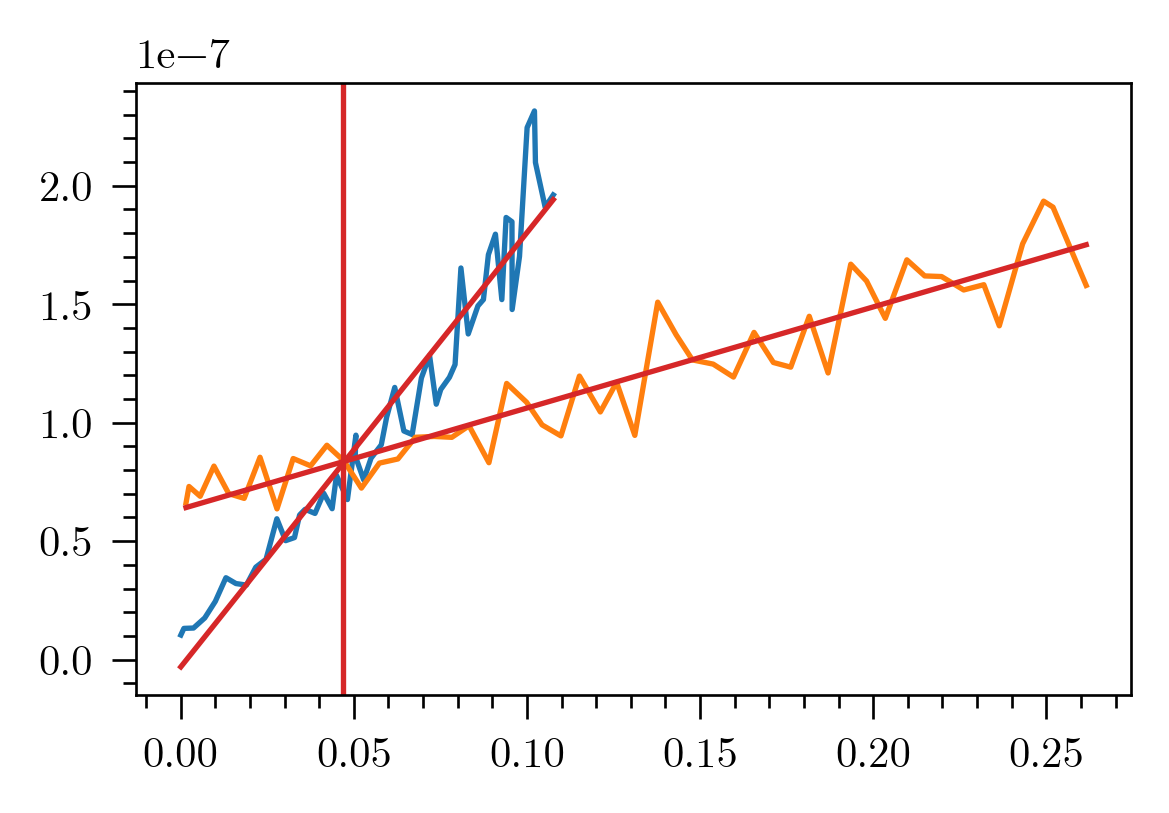

In [243]:
plt.plot(di_x, di_vars)
plt.plot(di_x, np.poly1d(np.polyfit(np.ravel(di_x), np.ravel(di_vars), 1))(di_x), 'tab:red')

plt.plot(spade_x, spade_vars)
plt.plot(spade_x, np.poly1d(np.polyfit(np.ravel(spade_x), np.ravel(spade_vars), 1))(spade_x), 'tab:red')

plt.axvline(0.047, color='tab:red')

In [ ]:
for d in range(0, 101, 2):
    m = 'spade'
    c = LoadEstimates(rf'data/noisy/{m}_5px_f0.2_d{d}.npz')
    plott(c.time_domain[0] / DI.SIGMA, title=rf'{m.upper()} (d{d});' + rf'$\quad b/\nu = {np.round(c.background / c.photons, 4)}$')

In [ ]:
for d in range(0, 101, 2):
    m = 'di'
    c = LoadEstimates(rf'data/noisy/{m}_5px_f0.2_d{d}.npz')
    plott(c.time_domain[0] / DI.SIGMA, title=rf'{m.upper()} (d{d});' + rf'$\quad b/\nu = {np.round(c.background / c.photons, 4)}$')

In [ ]:
spade_c = LoadEstimates('data/noisy/spade_5px_f0.2_d22.npz')
di_c = LoadEstimates('data/noisy/di_5px_f0.2_d38.npz')

In [236]:
spade_b = np.round(spade_c.background / spade_c.photons, 3)
di_b = np.round(di_c.background / di_c.photons, 3)

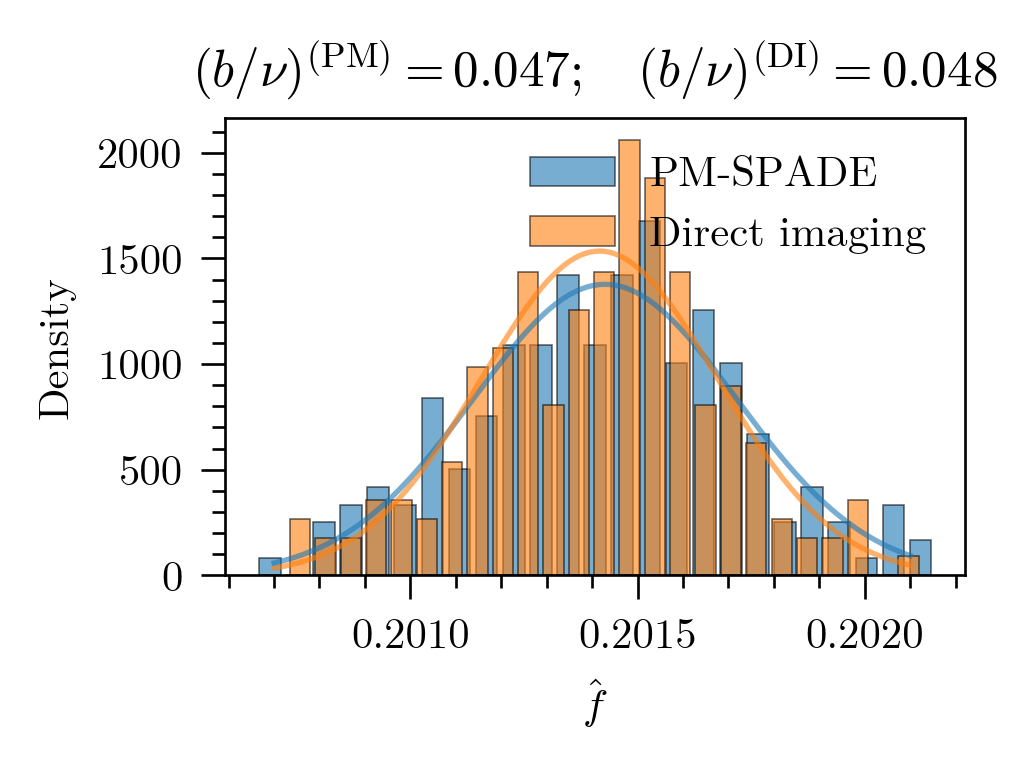

In [241]:
plt.hist(spade_c.estimates, bins=25, edgecolor='black', linewidth=0.3, align='mid', rwidth=0.8, alpha=0.6, density=True, label='PM-SPADE')
plt.hist(di_c.estimates, bins=25, edgecolor='black', linewidth=0.3, align='mid', rwidth=0.8, alpha=0.6, density=True, label='Direct imaging')


x_axis = np.linspace(0.2007, 0.2021, 300)
plt.plot(x_axis, norm(spade_c.estimates.mean(), spade_c.estimates.std()).pdf(x_axis), alpha=0.6, color='tab:blue')
plt.plot(x_axis, norm(di_c.estimates.mean(), di_c.estimates.std()).pdf(x_axis), alpha=0.6, color='tab:orange')


plt.legend(frameon=False)

plt.title(r'$(b/\nu)^\text{(PM)}'+ f' = {spade_b};\quad$' + r'$(b/\nu)^\text{(DI)}'+ f' = {di_b}$')
plt.xlabel(r'$\hat f$')
plt.ylabel(r'Density')

plt.gca().set_box_aspect(0.618)
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(np.linspace(0.20075, 0.20200, 300), norm(spade_c.estimates.mean(), spade_c.estimates.std()).pdf(np.linspace(0.20075, 0.20200, 300)))

In [1]:
from src import *
import matplotlib.pyplot as plt
from scipy.stats import norm

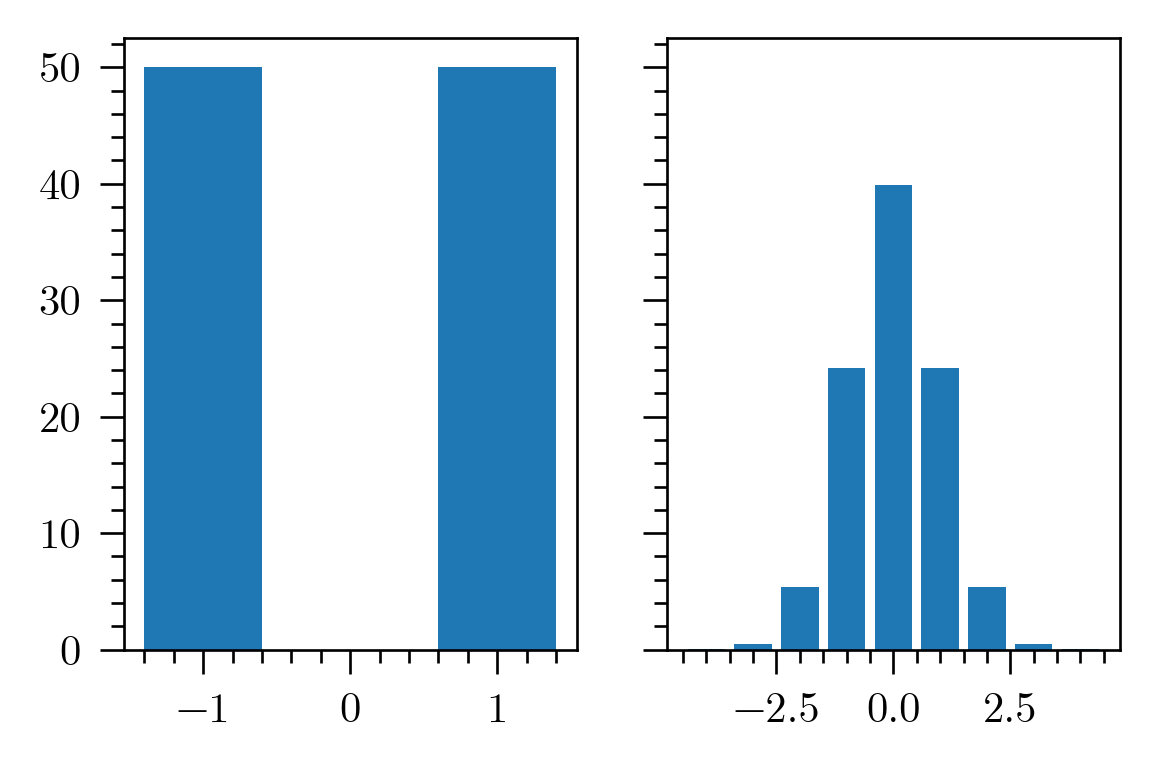

In [3]:
fig, ax = plt.subplots(1, 2, sharey= True)

ax[0].bar([-1, 1], [50, 50])
ax[1].bar(np.linspace(-4, 4, 9), 100 * norm(0, 1).pdf(np.linspace(-4, 4, 9)))
plt.show()

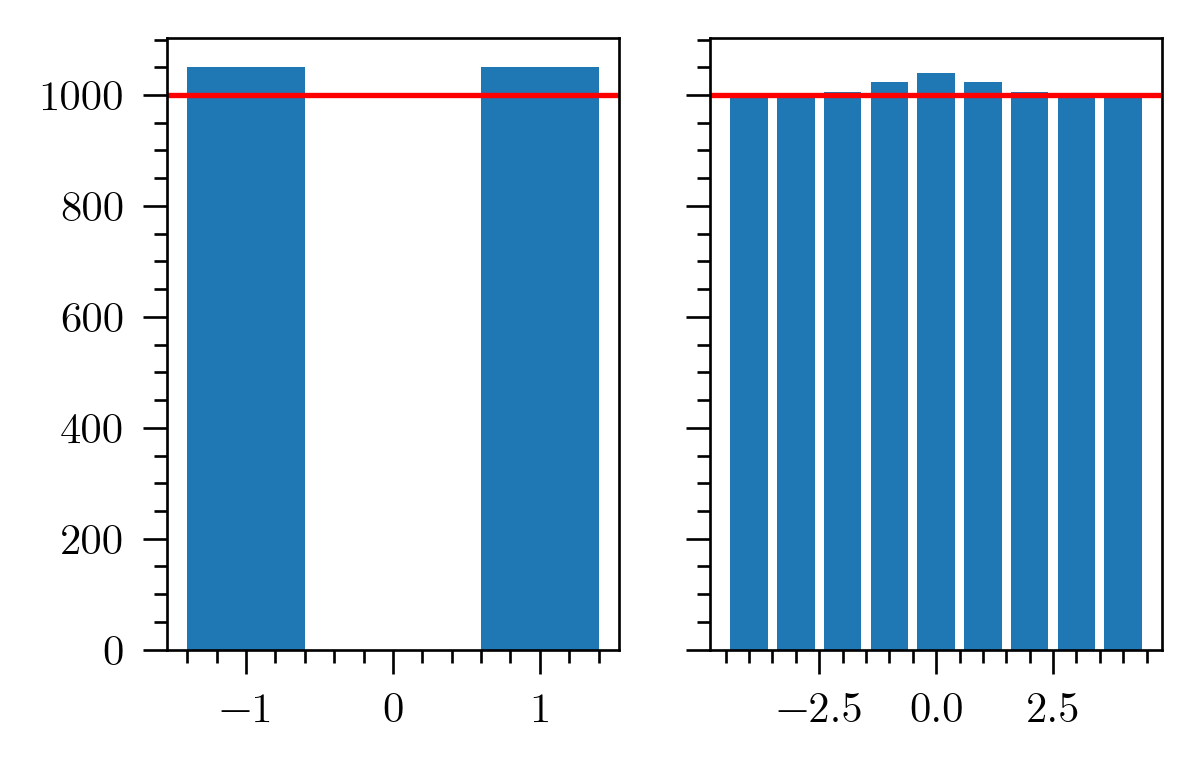

In [276]:
fig, ax = plt.subplots(1, 2, sharey= True)
noise = 1000


ax[0].bar([-1, 1], np.array([50, 50]) + noise)
ax[1].bar(np.linspace(-4, 4, 9), 100 * norm(0, 1).pdf(np.linspace(-4, 4, 9)) + noise)

ax[0].axhline(noise, color='r')
ax[1].axhline(noise, color='r')
plt.show()